# Vietnamese Malicious Comment Detection with XLM-RoBERTa
Binary classification: 0 = Clean, 1 = Malicious

## 1. Install & Import Libraries

In [1]:
!pip install transformers underthesea -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 54.6 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

from underthesea import word_tokenize
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

from transformers import (
    get_linear_schedule_with_warmup,
    AutoTokenizer,
    AutoModel,
    logging,
)

import warnings
warnings.filterwarnings("ignore")
logging.set_verbosity_error()

In [3]:
import torch

# Use GPU when available, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    props = torch.cuda.get_device_properties(0)
    print(f"Memory: {props.total_memory / 1024**3:.1f} GB")
else:
    print("GPU not available, using CPU")


Using device: cuda
GPU: Tesla T4
Memory: 14.6 GB


In [4]:
def seed_everything(seed_value):
    """Set seeds for reproducibility"""
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    try:
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed_value)
            torch.cuda.manual_seed_all(seed_value)
    except:
        pass

seed_everything(42)


In [ ]:
EPOCHS = 6
N_SPLITS = 5
BATCH_SIZE = 16
MAX_LEN = 128
LEARNING_RATE = 2e-5
MODEL_NAME = "xlm-roberta-base"
NUM_WORKERS = 0  # Kaggle does not support num_workers > 0 reliably

# Kaggle paths
import os
KAGGLE_INPUT = "/kaggle/input"
KAGGLE_OUTPUT = "/kaggle/working"

# Define data paths for Kaggle dataset structure
KAGGLE_DATASET_PATH = "/kaggle/input/datasets/viethoang0805/vietnamesebullydataset"

# Auto-detect: Kaggle or local
if os.path.exists(KAGGLE_DATASET_PATH):
    # Using Kaggle dataset
    DATA_CSV = os.path.join(KAGGLE_DATASET_PATH, "data.csv")
    STOPWORDS_PATH = os.path.join(KAGGLE_DATASET_PATH, "vietnamese_stopwords.txt")
    save_dir = KAGGLE_OUTPUT
elif os.path.exists(KAGGLE_INPUT):
    # Fallback: Try to find data in other Kaggle input directories
    DATA_DIR = None
    for d in os.listdir(KAGGLE_INPUT):
        candidate = os.path.join(KAGGLE_INPUT, d)
        if os.path.isfile(os.path.join(candidate, "data.csv")) or \
           os.path.isfile(os.path.join(candidate, "data", "data.csv")):
            DATA_DIR = candidate
            break
    if DATA_DIR is None:
        DATA_DIR = os.path.join(KAGGLE_INPUT, os.listdir(KAGGLE_INPUT)[0]) if os.listdir(KAGGLE_INPUT) else "."
    
    if os.path.isfile(os.path.join(DATA_DIR, "data.csv")):
        DATA_CSV = os.path.join(DATA_DIR, "data.csv")
        STOPWORDS_PATH = os.path.join(DATA_DIR, "vietnamese_stopwords.txt")
    else:
        DATA_CSV = os.path.join(DATA_DIR, "data", "data.csv")
        STOPWORDS_PATH = os.path.join(DATA_DIR, "data", "vietnamese_stopwords.txt")
    save_dir = KAGGLE_OUTPUT
else:
    # Local development
    DATA_CSV = "data/data.csv"
    STOPWORDS_PATH = "data/vietnamese_stopwords.txt"
    save_dir = "."

print(f"Data CSV      : {DATA_CSV}")
print(f"Stopwords     : {STOPWORDS_PATH}")
print(f"Output dir    : {save_dir}")

Data CSV      : /kaggle/input/datasets/viethoang0805/vietnamesebullydataset/data.csv
Stopwords     : /kaggle/input/datasets/viethoang0805/vietnamesebullydataset/vietnamese_stopwords.txt
Output dir    : /kaggle/working


## 2. Load Dataset & Stopwords

In [6]:
data = pd.read_csv(DATA_CSV)
data = data.iloc[:, 1:]
print(data.info())
print(f"\nLabel distribution:\n{data['label'].value_counts()}")
data.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11056 entries, 0 to 11055
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  11056 non-null  object
 1   label    11056 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 172.9+ KB
None

Label distribution:
label
0    5696
1    5360
Name: count, dtype: int64


,content,label
0,Dừa lắm :)),0
1,Bấp bênh vl thế,1
2,Chắc cũng biết ko tồn tại đc bao lâu nữa nên c...,1
3,Thấy chán ad page này kiến thức thì nông cản c...,1
4,Giang Giang Đỗ Thị Ngọc Hà trend mới kìa kìa,0
5,đcm 😒 sau có con cho hút cỏ chữa bệnh chứ đéo ...,1
6,Má nứng quá aiu ơi,1
7,Chụp cái ảnh thôi làm đéo gì đâu mà phiền,1
8,Tăng theo giờ 😭😭😭,0
9,Cực kì thuyết phục :c,0


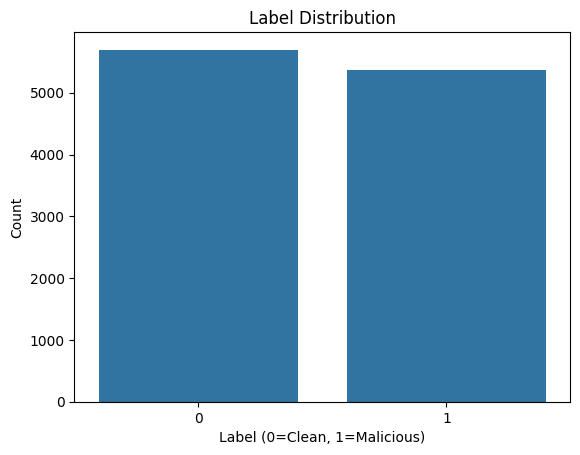

In [7]:
sns.countplot(x='label', data=data)
plt.title('Label Distribution')
plt.xlabel('Label (0=Clean, 1=Malicious)')
plt.ylabel('Count')
plt.show()

In [8]:
with open(STOPWORDS_PATH, 'r', encoding='utf-8') as f:
    stopwords = set(line.strip() for line in f.readlines())

print(f"Loaded {len(stopwords)} stopwords")
print(f"Sample: {list(stopwords)[:10]}")

Loaded 1942 stopwords
Sample: ['ổng', 'sáng ý', 'ờ', 'ba ngôi', 'sang tay', 'nhất loạt', 'phía dưới', 'giờ này', 'có được', 'nguồn']


## 3. Text Preprocessing

In [9]:
def preprocess_text(text, remove_stopwords=True):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^\w\s\u00C0-\u024F\u1E00-\u1EFF]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = word_tokenize(text, format="text")
    if remove_stopwords:
        words = text.split()
        words = [w for w in words if w not in stopwords]
        text = ' '.join(words)
    return text

sample = data.iloc[3]['content']
print(f"Original : {sample}")
print(f"Processed: {preprocess_text(sample)}")

Original : Thấy chán ad page này kiến thức thì nông cản cái gì cũng auto sủa, cái nhìn thì tiêu cực, nói chung là dốt còn nát
Processed: chán ad_page kiến_thức nông_cản auto_sủa tiêu_cực nói_chung dốt nát


In [10]:
data['content_clean'] = data['content'].apply(preprocess_text)
data[['content', 'content_clean', 'label']].head(10)

,content,content_clean,label
0,Dừa lắm :)),dừa lắm,0
1,Bấp bênh vl thế,bấp_bênh vl,1
2,Chắc cũng biết ko tồn tại đc bao lâu nữa nên c...,ko tồn_tại đc bao_lâu cố_gắng vét,1
3,Thấy chán ad page này kiến thức thì nông cản c...,chán ad_page kiến_thức nông_cản auto_sủa tiêu_...,1
4,Giang Giang Đỗ Thị Ngọc Hà trend mới kìa kìa,giang_giang đỗ_thị ngọc_hà trend kìa kìa,0
5,đcm 😒 sau có con cho hút cỏ chữa bệnh chứ đéo ...,đcm hút cỏ chữa bệnh đéo đi bệnh_viện,1
6,Má nứng quá aiu ơi,má nứng aiu,1
7,Chụp cái ảnh thôi làm đéo gì đâu mà phiền,chụp ảnh đéo phiền,1
8,Tăng theo giờ 😭😭😭,,0
9,Cực kì thuyết phục :c,cực_kì thuyết_phục c,0


## 4. Train/Test Split

In [11]:
train_df = data.iloc[:int(len(data) * 0.8)].reset_index(drop=True)
test_df = data.iloc[int(len(data) * 0.8):].reset_index(drop=True)

print(f"Train size: {len(train_df)}")
print(f"Test size : {len(test_df)}")
print(f"\nTrain label distribution:\n{train_df['label'].value_counts()}")
print(f"\nTest label distribution:\n{test_df['label'].value_counts()}")

Train size: 8844
Test size : 2212

Train label distribution:
label
0    4552
1    4292
Name: count, dtype: int64

Test label distribution:
label
0    1144
1    1068
Name: count, dtype: int64


In [12]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=86)
for fold, (_, val_) in enumerate(skf.split(X=train_df, y=train_df.label)):
    train_df.loc[val_, "kfold"] = fold

train_df['kfold'] = train_df['kfold'].astype(int)
train_df.head()

,content,label,content_clean,kfold
0,Dừa lắm :)),0,dừa lắm,2
1,Bấp bênh vl thế,1,bấp_bênh vl,4
2,Chắc cũng biết ko tồn tại đc bao lâu nữa nên c...,1,ko tồn_tại đc bao_lâu cố_gắng vét,3
3,Thấy chán ad page này kiến thức thì nông cản c...,1,chán ad_page kiến_thức nông_cản auto_sủa tiêu_...,0
4,Giang Giang Đỗ Thị Ngọc Hà trend mới kìa kìa,0,giang_giang đỗ_thị ngọc_hà trend kìa kìa,1


## 5. Tokenizer & Dataset

In [13]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
print(f"Vocab size: {tokenizer.vocab_size}")

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocab size: 64000


Max token length : 170
Mean token length: 10.4
95th percentile  : 26


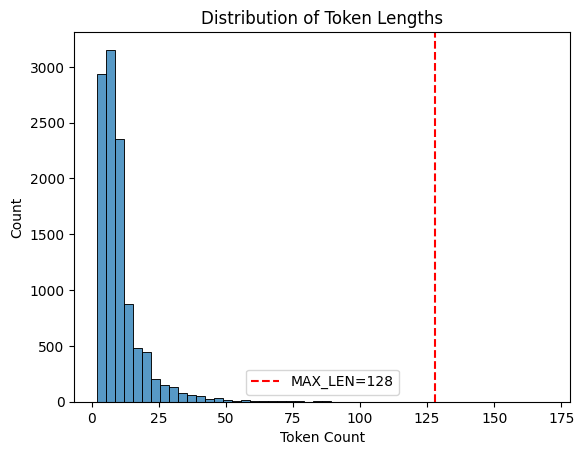

In [14]:
all_texts = data['content_clean'].tolist()
encoded_texts = [tokenizer.encode(text, add_special_tokens=True) for text in all_texts]
token_lens = [len(t) for t in encoded_texts]

print(f"Max token length : {max(token_lens)}")
print(f"Mean token length: {np.mean(token_lens):.1f}")
print(f"95th percentile  : {np.percentile(token_lens, 95):.0f}")

sns.histplot(token_lens, bins=50)
plt.xlabel('Token Count')
plt.title('Distribution of Token Lengths')
plt.axvline(x=MAX_LEN, color='r', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
plt.legend()
plt.show()

In [15]:
class SentimentDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.df = df
        self.max_len = max_len
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        text = row['content_clean']
        label = row['label']

        encoding = self.tokenizer(
            text,
            truncation=True,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            return_attention_mask=True,
            return_token_type_ids=False,
            return_tensors='pt',
        )

        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_masks': encoding['attention_mask'].flatten(),
            'targets': torch.tensor(label, dtype=torch.long),
        }


In [16]:
def prepare_loaders(df, fold):
    df_train = df[df.kfold != fold].reset_index(drop=True)
    df_valid = df[df.kfold == fold].reset_index(drop=True)

    train_dataset = SentimentDataset(df_train, tokenizer, max_len=MAX_LEN)
    valid_dataset = SentimentDataset(df_valid, tokenizer, max_len=MAX_LEN)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    return train_loader, valid_loader

## 6. Model Definition

In [ ]:
class SentimentClassifier(nn.Module):
    def __init__(self, n_classes=2, dropout=0.3):
        super(SentimentClassifier, self).__init__()
        self.encoder = AutoModel.from_pretrained(MODEL_NAME)
        self.drop = nn.Dropout(p=dropout)
        self.fc = nn.Linear(self.encoder.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
        )
        cls_token = outputs.last_hidden_state[:, 0, :]
        x = self.drop(cls_token)
        x = self.fc(x)
        return x


## 7. Training & Evaluation Functions

In [18]:
def train_epoch(model, criterion, optimizer, scheduler, train_loader):
    model.train()
    losses = []
    correct = 0
    total = 0

    for data in train_loader:
        input_ids = data['input_ids'].to(device)
        attention_mask = data['attention_masks'].to(device)
        targets = data['targets'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs, targets)

        _, pred = torch.max(outputs, dim=1)
        correct += torch.sum(pred == targets).item()
        total += targets.size(0)
        losses.append(loss.item())

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

    acc = correct / total
    avg_loss = np.mean(losses)
    return acc, avg_loss


def eval_epoch(model, criterion, data_loader):
    model.eval()
    losses = []
    correct = 0
    total = 0

    with torch.no_grad():
        for data in data_loader:
            input_ids = data['input_ids'].to(device)
            attention_mask = data['attention_masks'].to(device)
            targets = data['targets'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, targets)

            _, pred = torch.max(outputs, dim=1)
            correct += torch.sum(pred == targets).item()
            total += targets.size(0)
            losses.append(loss.item())

    acc = correct / total
    avg_loss = np.mean(losses)
    return acc, avg_loss

## 8. K-Fold Training

In [ ]:
fold_results = []

for fold in range(N_SPLITS):
    print(f'\n{"="*60}')
    print(f'FOLD {fold + 1}/{N_SPLITS}')
    print(f'{"="*60}')

    train_loader, valid_loader = prepare_loaders(train_df, fold=fold)

    model = SentimentClassifier(n_classes=2).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
    
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=total_steps,
    )

    best_val_acc = 0
    for epoch in range(EPOCHS):
        train_acc, train_loss = train_epoch(model, criterion, optimizer, scheduler, train_loader)
        val_acc, val_loss = eval_epoch(model, criterion, valid_loader)

        print(f'Epoch {epoch+1}/{EPOCHS} | '
              f'Train Acc: {train_acc:.4f} Loss: {train_loss:.4f} | '
              f'Val Acc: {val_acc:.4f} Loss: {val_loss:.4f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            os.makedirs(save_dir, exist_ok=True)
            torch.save(model.state_dict(), os.path.join(save_dir, f'xlmr_fold{fold+1}.pth'))

    fold_results.append(best_val_acc)
    print(f'Best Val Accuracy for Fold {fold+1}: {best_val_acc:.4f}')

print(f'\n{"="*60}')
print(f'Average Val Accuracy: {np.mean(fold_results):.4f} (+/- {np.std(fold_results):.4f})')



FOLD 1/5


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Epoch 1/6 | Train Acc: 0.7549 Loss: 0.4940 | Val Acc: 0.8502 Loss: 0.3414
Epoch 2/6 | Train Acc: 0.8718 Loss: 0.3151 | Val Acc: 0.8768 Loss: 0.3322
Epoch 3/6 | Train Acc: 0.9087 Loss: 0.2411 | Val Acc: 0.8807 Loss: 0.3299
Epoch 4/6 | Train Acc: 0.9357 Loss: 0.1875 | Val Acc: 0.8785 Loss: 0.3888
Epoch 5/6 | Train Acc: 0.9521 Loss: 0.1544 | Val Acc: 0.8954 Loss: 0.4150
Epoch 6/6 | Train Acc: 0.9613 Loss: 0.1249 | Val Acc: 0.8932 Loss: 0.4584
Best Val Accuracy for Fold 1: 0.8954

FOLD 2/5


...

Epoch 1/6 | Train Acc: 0.7765 Loss: 0.4626 | Val Acc: 0.8587 Loss: 0.3441
Epoch 2/6 | Train Acc: 0.8787 Loss: 0.3011 | Val Acc: 0.8779 Loss: 0.3259
Epoch 3/6 | Train Acc: 0.9166 Loss: 0.2304 | Val Acc: 0.8802 Loss: 0.3650
Epoch 4/6 | Train Acc: 0.9398 Loss: 0.1860 | Val Acc: 0.8813 Loss: 0.4199
Epoch 5/6 | Train Acc: 0.9590 Loss: 0.1381 | Val Acc: 0.8932 Loss: 0.4377
Epoch 6/6 | Train Acc: 0.9668 Loss: 0.1154 | Val Acc: 0.8875 Loss: 0.4763
Best Val Accuracy for Fold 3: 0.8932

FOLD 4/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Epoch 1/6 | Train Acc: 0.7754 Loss: 0.4643 | Val Acc: 0.8434 Loss: 0.3610
Epoch 2/6 | Train Acc: 0.8770 Loss: 0.3032 | Val Acc: 0.8395 Loss: 0.4538
Epoch 3/6 | Train Acc: 0.9190 Loss: 0.2287 | Val Acc: 0.8790 Loss: 0.3923
Epoch 4/6 | Train Acc: 0.9378 Loss: 0.1861 | Val Acc: 0.8751 Loss: 0.4148
Epoch 5/6 | Train Acc: 0.9596 Loss: 0.1322 | Val Acc: 0.8785 Loss: 0.5068
Epoch 6/6 | Train Acc: 0.9665 Loss: 0.1165 | Val Acc: 0.8796 Loss: 0.5566
Best Val Accuracy for Fold 4: 0.8796

FOLD 5/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Epoch 1/6 | Train Acc: 0.7753 Loss: 0.4652 | Val Acc: 0.8529 Loss: 0.3413
Epoch 2/6 | Train Acc: 0.8741 Loss: 0.3087 | Val Acc: 0.8654 Loss: 0.3324
Epoch 3/6 | Train Acc: 0.9152 Loss: 0.2333 | Val Acc: 0.8773 Loss: 0.3791
Epoch 4/6 | Train Acc: 0.9382 Loss: 0.1802 | Val Acc: 0.8722 Loss: 0.4300
Epoch 5/6 | Train Acc: 0.9576 Loss: 0.1382 | Val Acc: 0.8801 Loss: 0.5183
Epoch 6/6 | Train Acc: 0.9681 Loss: 0.1199 | Val Acc: 0.8767 Loss: 0.5656
Best Val Accuracy for Fold 5: 0.8801

Average Val Accuracy: 0.8873 (+/- 0.0065)


## 9. Test Evaluation (Ensemble)

In [ ]:
def test_ensemble(test_df, tokenizer, n_folds=N_SPLITS):
    models = []
    for fold in range(n_folds):
        try:
            model_path = os.path.join(save_dir, f'xlmr_fold{fold+1}.pth')
            if os.path.exists(model_path):
                m = SentimentClassifier(n_classes=2).to(device)
                m.load_state_dict(torch.load(model_path, map_location=device))
                m.eval()
                models.append(m)
        except Exception as e:
            print(f"Warning: Could not load fold {fold+1}: {e}")

    if not models:
        print("Error: No models loaded!")
        return None, None, None

    test_dataset = SentimentDataset(test_df, tokenizer, max_len=MAX_LEN)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    all_preds = []
    all_targets = []
    all_texts = []

    with torch.no_grad():
        for data in test_loader:
            input_ids = data['input_ids'].to(device)
            attention_mask = data['attention_masks'].to(device)
            targets = data['targets']

            fold_outputs = []
            for m in models:
                outputs = m(input_ids=input_ids, attention_mask=attention_mask)
                fold_outputs.append(outputs)

            avg_outputs = torch.stack(fold_outputs).mean(0)
            _, preds = torch.max(avg_outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.numpy())
            all_texts.extend(data['text'])

    return np.array(all_targets), np.array(all_preds), all_texts


In [21]:
print("Evaluating on test set...")
real_values, predicts, texts = test_ensemble(test_df, tokenizer)

if real_values is not None:
    print("\n" + "="*60)
    print(classification_report(real_values, predicts, target_names=['Clean (0)', 'Malicious (1)']))
    print("="*60)
else:
    print("Could not evaluate - models not available yet")


Evaluating on test set...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


               precision    recall  f1-score   support

    Clean (0)       0.89      0.90      0.89      1144
Malicious (1)       0.89      0.87      0.88      1068

     accuracy                           0.89      2212
    macro avg       0.89      0.89      0.89      2212
 weighted avg       0.89      0.89      0.89      2212



## 10. Confusion Matrix

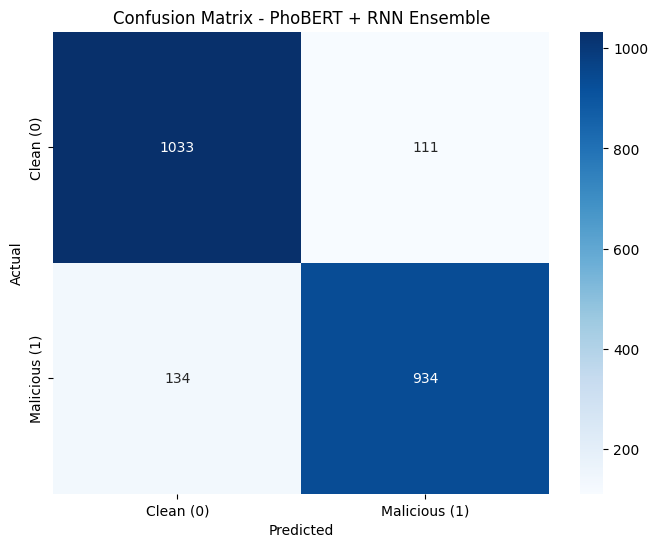

In [ ]:
if real_values is not None:
    cm = confusion_matrix(real_values, predicts)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Clean (0)', 'Malicious (1)'],
                yticklabels=['Clean (0)', 'Malicious (1)'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - XLM-RoBERTa Ensemble')
    plt.show()
else:
    print("Cannot create confusion matrix - run test evaluation first")


## 11. Error Analysis

In [23]:
if real_values is not None:
    wrong_indices = np.where(predicts != real_values)[0]
    print(f"Total wrong predictions: {len(wrong_indices)} / {len(real_values)}")
    print(f"Error rate: {len(wrong_indices)/len(real_values)*100:.2f}%\n")

    for i in wrong_indices[:15]:
        print('-' * 60)
        print(f"Text: {test_df.iloc[i]['content']}")
        print(f"Predicted: {predicts[i]} | Actual: {real_values[i]}")
else:
    print("Cannot analyze errors - run test evaluation first")


Total wrong predictions: 245 / 2212
Error rate: 11.08%

------------------------------------------------------------
Text: đungs v
Predicted: 1 | Actual: 0
------------------------------------------------------------
Text: Lũ pede xạo xự. Mới hơm qua chúng tâng nhau lên mây. Nay chúng siủa cắn nhau như chó tháng 7. Hahaaaaaaa
Predicted: 0 | Actual: 1
------------------------------------------------------------
Text: tr ơi nhìn thầy giống con póng quá à.
Predicted: 0 | Actual: 1
------------------------------------------------------------
Text: nó ko cộng điểm, mà nó cho thí sinh rớt bớt thôi, có bà chị gặp vụ này r :)))) thi điểm cao vẫn rớt nhé
Predicted: 0 | Actual: 1
------------------------------------------------------------
Text: 90tr dân Việt Nam đang vả nhung nè
Predicted: 0 | Actual: 1
------------------------------------------------------------
Text: Chac tui chot wa cuoi dau bug luon
Predicted: 1 | Actual: 0
---------------------------------------------------------

## 12. Inference

In [24]:
def predict(text, tokenizer, model, device):
    """Predict sentiment for a given text"""
    label_map = {0: 'Clean', 1: 'Malicious'}
    processed = preprocess_text(text)

    encoding = tokenizer(
        processed,
        max_length=MAX_LEN,
        truncation=True,
        add_special_tokens=True,
        padding='max_length',
        return_attention_mask=True,
        return_token_type_ids=False,
        return_tensors='pt',
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    model.eval()
    with torch.no_grad():
        output = model(input_ids, attention_mask)
        probs = torch.softmax(output, dim=1)
        confidence, pred = torch.max(probs, dim=1)

    label = label_map[pred.item()]
    conf = confidence.item()
    
    print(f"Text       : {text}")
    print(f"Prediction : {label} (confidence: {conf:.4f})")
    return label, conf


In [ ]:
if len(fold_results) > 0:
    best_fold = np.argmax(fold_results) + 1
    model_path = os.path.join(save_dir, f'xlmr_fold{best_fold}.pth')
    
    if os.path.exists(model_path):
        print(f"Loading best model from fold {best_fold}")
        best_model = SentimentClassifier(n_classes=2).to(device)
        best_model.load_state_dict(torch.load(model_path, map_location=device))
        best_model.eval()

        print("\n" + "="*60)
        print("Testing on sample sentences:")
        print("="*60)
        
        test_sentences = [
            "Ban lam tot lam, co gang nhe!",
            "Thang ngu, do vo dung",
            "Hom nay troi dep qua",
            "Do con cho, may bien di",
            "Cam on ban rat nhieu",
        ]

        for sentence in test_sentences:
            predict(sentence, tokenizer, best_model, device)
            print()
    else:
        print(f"Model file not found: {model_path}")
else:
    print("No fold results available - train the model first")


Loading best model from fold 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Testing on sample sentences:
Text       : Ban lam tot lam, co gang nhe!
Prediction : Clean (confidence: 0.6874)

Text       : Thang ngu, do vo dung
Prediction : Malicious (confidence: 0.9985)

Text       : Hom nay troi dep qua
Prediction : Clean (confidence: 0.9955)

Text       : Do con cho, may bien di
Prediction : Clean (confidence: 0.6038)

Text       : Cam on ban rat nhieu
Prediction : Clean (confidence: 0.9967)



## 13. Save Model & Tokenizer

In [ ]:
if len(fold_results) > 0:
    best_fold = np.argmax(fold_results) + 1
    model_path = os.path.join(save_dir, f'xlmr_fold{best_fold}.pth')
    
    if os.path.exists(model_path):
        output_dir = os.path.join(save_dir, "xlmr_malicious_detection")
        os.makedirs(output_dir, exist_ok=True)

        # Load and save best model
        best_model = SentimentClassifier(n_classes=2).to(device)
        best_model.load_state_dict(torch.load(model_path, map_location=device))
        torch.save(best_model.state_dict(), os.path.join(output_dir, 'xlmr_best.pth'))
        
        # Save tokenizer
        tokenizer.save_pretrained(output_dir)

        print(f"✓ Model and tokenizer saved to: {output_dir}")
        print(f"\nFiles saved:")
        for f in sorted(os.listdir(output_dir)):
            file_path = os.path.join(output_dir, f)
            file_size = os.path.getsize(file_path) / (1024 * 1024)
            print(f"  - {f} ({file_size:.1f} MB)")
    else:
        print(f"Model file not found: {model_path}")
else:
    print("No trained models available - complete training first")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✓ Model and tokenizer saved to: /kaggle/working/phobert_rnn_malicious_detection

Files saved:
  - added_tokens.json (0.0 MB)
  - bpe.codes (1.1 MB)
  - phobert_rnn_best.pth (521.1 MB)
  - tokenizer_config.json (0.0 MB)
  - vocab.txt (0.9 MB)
